# Objective 4 — Skill & Learning Resource Recommendation

Loads missing skills from Objective 3, prepares the Coursera course dataset, and recommends relevant courses for missing skills using TF-IDF and SBERT-based ranking.

## Install Packages

In [3]:
# Run once
!pip -q install pandas numpy scikit-learn matplotlib seaborn sentence-transformers scipy
!pip install datasets

## Import Libraries

In [5]:
import os, re, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')
import pickle
import json
from scipy.sparse import save_npz, load_npz
from sentence_transformers import SentenceTransformer

Libraries loaded.


## Step 1: Load Skill Gap Results from Objective 3

In [7]:
gap_df = pd.read_csv('data/skill_gap_results.csv')

def parse_list(val):
    if isinstance(val, list): return val
    try: return ast.literal_eval(str(val))
    except: return []

gap_df['missing_skills']  = gap_df['missing_skills'].apply(parse_list)
gap_df['matched_skills']  = gap_df['matched_skills'].apply(parse_list)
gap_df['required_skills'] = gap_df['required_skills'].apply(parse_list)

all_missing = []
for lst in gap_df['missing_skills']:
    all_missing.extend(lst)
unique_missing = sorted(set(all_missing))

print(f'Jobs loaded          : {len(gap_df)}')
print(f'Unique missing skills: {len(unique_missing)}')
print(f'Missing skills       : {unique_missing}')
gap_df[['rank','job_title','match_pct','gap_score']]

Jobs loaded          : 10
Unique missing skills: 29
Missing skills       : ['.net', 'agile', 'angular', 'aws', 'azure', 'bootstrap', 'communication', 'data mining', 'docker', 'express', 'fastapi', 'git', 'jquery', 'kafka', 'kubernetes', 'laravel', 'leadership', 'linux', 'mongodb', 'oracle', 'php', 'presentation', 'react', 'redis', 'sap', 'seo', 'spring', 'teamwork', 'vue']


,rank,job_title,match_pct,gap_score
0,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",63.64,0.364
1,2,Analyst Programmer,35.29,0.647
2,3,Junior PHP Developer,57.14,0.429
3,4,Junior PHP Web Developer,57.14,0.429
4,5,Java Programmer (Executive),85.71,0.143
5,6,"System Developer (React Native, PHP, MySQL/MS ...",55.56,0.444
6,7,FULLSTACK DEVELOPER,26.32,0.737
7,8,Java Developer,63.64,0.364
8,9,Software Engineer - Java Web,55.56,0.444
9,10,FULL STACK DEVELOPER,50.00,0.500


## Step 2: Load and Prepare Coursera Course Dataset

In [9]:
import os
import pandas as pd
from datasets import load_dataset

os.makedirs('data', exist_ok=True)

course_path = 'data/coursera_course_dataset.csv'

if os.path.exists(course_path):
    courses_df = pd.read_csv(course_path)
    source_used = course_path
else:
    ds = load_dataset('azrai99/coursera-course-dataset')
    split_name = 'train' if 'train' in ds else list(ds.keys())[0]
    courses_df = ds[split_name].to_pandas()
    courses_df.to_csv(course_path, index=False)
    source_used = 'azrai99/coursera-course-dataset'

print('Course dataset source:', source_used)
print('Original shape:', courses_df.shape)
print('Original columns:', courses_df.columns.tolist())

rename_map = {}
for col in courses_df.columns:
    key = str(col).strip().lower().replace('_', ' ')
    if key in ['title', 'course name', 'name', 'course title', 'course']:
        rename_map[col] = 'Title'
    elif key in ['organization', 'university', 'provider', 'org', 'institution', 'partner']:
        rename_map[col] = 'Organization'
    elif key in ['skills', 'skill tags', 'tags', 'topics', 'keywords']:
        rename_map[col] = 'Skills'
    elif key in ['ratings', 'course rating', 'rating', 'stars', 'score']:
        rename_map[col] = 'Ratings'
    elif key in ['course url', 'course_url', 'url', 'link', 'course link']:
        rename_map[col] = 'course_url'
    elif key in ['course description', 'course_description', 'description', 'desc', 'about', 'summary']:
        rename_map[col] = 'course_description'
    elif key in ['difficulty', 'difficulty level', 'level', 'course level']:
        rename_map[col] = 'Difficulty'
    elif key in ['duration', 'schedule']:
        rename_map[col] = 'Duration'

courses_df = courses_df.rename(columns=rename_map)

for col in ['Title', 'Organization', 'Skills', 'Ratings', 'course_url', 'course_description', 'Difficulty', 'Duration']:
    same_cols = [c for c in courses_df.columns if c == col]
    if len(same_cols) > 1:
        block = courses_df.loc[:, same_cols]
        combined = block.bfill(axis=1).iloc[:, 0]
        courses_df = courses_df.drop(columns=same_cols)
        courses_df[col] = combined

needed_cols = ['Title', 'Organization', 'Skills', 'Ratings', 'course_url', 'course_description', 'Difficulty', 'Duration']
for col in needed_cols:
    if col not in courses_df.columns:
        courses_df[col] = ''

courses_df = courses_df[needed_cols].copy()

print('Selected columns:', courses_df.columns.tolist())
courses_df.head(3)

Course dataset source: data/coursera_course_dataset.csv
Original shape: (6645, 14)
Original columns: ['Unnamed: 0', 'title', 'enrolled', 'rating', 'num_reviews', 'Instructor', 'Organization', 'Skills', 'Description', 'Modules/Courses', 'Level', 'Schedule', 'URL', 'Satisfaction Rate']
Selected columns: ['Title', 'Organization', 'Skills', 'Ratings', 'course_url', 'course_description', 'Difficulty', 'Duration']


,Title,Organization,Skills,Ratings,course_url,course_description,Difficulty,Duration
0,Analytical Solutions to Common Healthcare Prob...,"University of California, Davis",[],4.6,https://www.coursera.org/learn/analytical-solu...,"In this course, we’re going to go over analyti...",Intermediate level,10 hours to complete (3 weeks at 3 hours a week)
1,Understanding Einstein: The Special Theory of ...,Stanford University,[],4.9,https://www.coursera.org/learn/einstein-relati...,In this course we will seek to “understand Ein...,Beginner level,NaN
2,JavaScript for Beginners Specialization,"University of California, Davis","['web interactivty', 'Jquery', 'Data Manipulat...",4.7,https://www.coursera.org/specializations/javas...,This Specialization is intended for the learne...,Beginner level,2 months (at 10 hours a week)


## Step 3: EDA on Prepared Coursera Dataset

In [11]:
print('=' * 50)
print('EDA — Coursera Dataset')
print('=' * 50)
print(f'Total courses: {len(courses_df):,}')
print(f'Columns      : {courses_df.columns.tolist()}')

missing = courses_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nMissing values:\n{missing}')

def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    return None

# Detect course columns
COURSE_NAME_COL   = detect_col(courses_df, ['Title','Course Name','name','title','course_title','course_name','Name'])
COURSE_DESC_COL   = detect_col(courses_df, ['course_description','Course Description','description','desc','about','summary','Description'])
COURSE_SKILLS_COL = detect_col(courses_df, ['Skills','skills','skill_tags','tags','topics','Keywords'])
COURSE_ORG_COL    = detect_col(courses_df, ['Organization','University','organization','org','provider','institution'])
COURSE_RATING_COL = detect_col(courses_df, ['Ratings','Course Rating','Rating','rating','stars','score'])
COURSE_DIFF_COL   = detect_col(courses_df, ['Difficulty','Difficulty Level','level','difficulty','course_level','Level'])
COURSE_URL_COL    = detect_col(courses_df, ['course_url','url','link','course_url','URL','Course URL'])

print(f'\nDetected columns:')
print(f'  Name      : {COURSE_NAME_COL}')
print(f'  Desc      : {COURSE_DESC_COL}')
print(f'  Skills    : {COURSE_SKILLS_COL}')
print(f'  Org       : {COURSE_ORG_COL}')
print(f'  Rating    : {COURSE_RATING_COL}')
print(f'  Difficulty: {COURSE_DIFF_COL}')
print(f'  URL       : {COURSE_URL_COL}')

if COURSE_NAME_COL is None:
    raise ValueError(f'Course name column not found. CSV columns: {courses_df.columns.tolist()}')

EDA — Coursera Dataset
Total courses: 6,645
Columns      : ['Title', 'Organization', 'Skills', 'Ratings', 'course_url', 'course_description', 'Difficulty', 'Duration']

Missing values:
Duration              1888
Difficulty             778
course_description      10
dtype: int64

Detected columns:
  Name      : Title
  Desc      : course_description
  Skills    : Skills
  Org       : Organization
  Rating    : Ratings
  Difficulty: Difficulty
  URL       : course_url


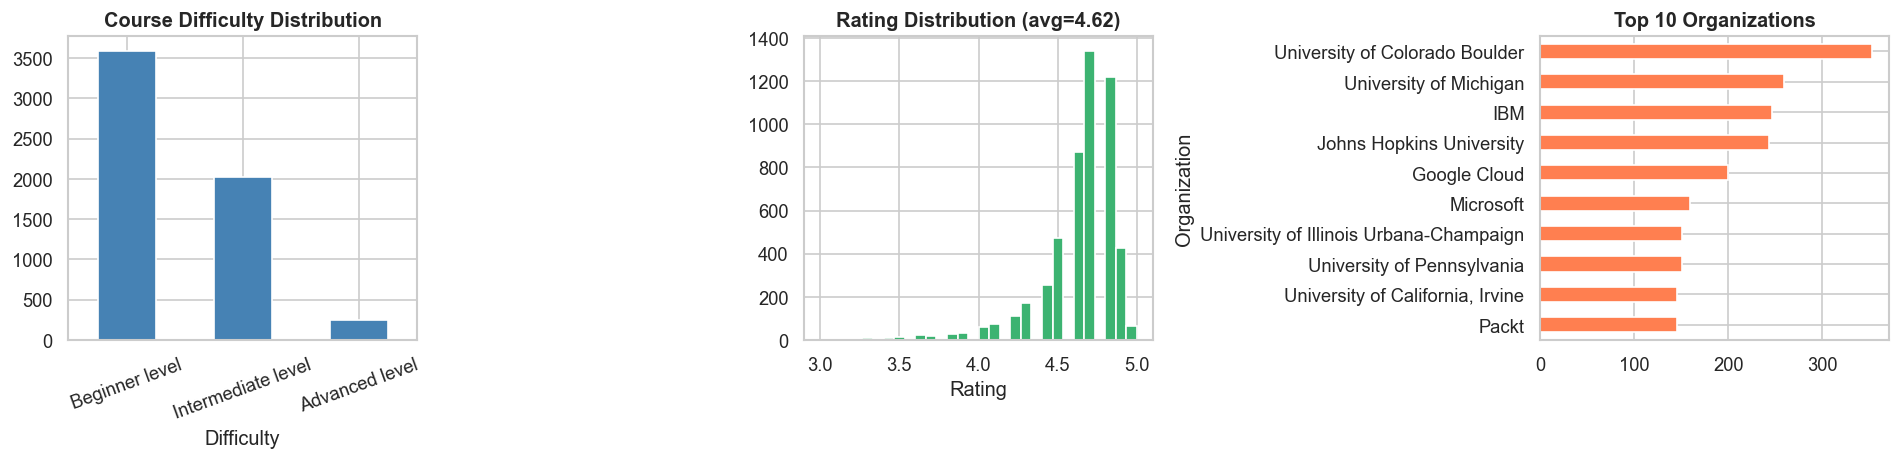

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if COURSE_DIFF_COL:
    diff_counts = courses_df[COURSE_DIFF_COL].value_counts()
    diff_counts.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Course Difficulty Distribution', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=20)

if COURSE_RATING_COL:
    ratings = pd.to_numeric(courses_df[COURSE_RATING_COL], errors='coerce').dropna()
    axes[1].hist(ratings, bins=30, color='mediumseagreen', edgecolor='white')
    axes[1].set_title(f'Rating Distribution (avg={ratings.mean():.2f})', fontweight='bold')
    axes[1].set_xlabel('Rating')

if COURSE_ORG_COL:
    top_orgs = courses_df[COURSE_ORG_COL].value_counts().head(10)
    top_orgs.plot(kind='barh', ax=axes[2], color='coral')
    axes[2].set_title('Top 10 Organizations', fontweight='bold')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 4: Preprocessing

In [14]:
before = len(courses_df)

courses_df['Title'] = courses_df['Title'].fillna('').astype(str).str.strip()
courses_df = courses_df[courses_df['Title'] != '']

courses_df['Organization'] = courses_df['Organization'].fillna('Not specified').astype(str).str.strip()
courses_df['Skills'] = courses_df['Skills'].fillna('').astype(str).str.strip()
courses_df['course_description'] = courses_df['course_description'].fillna('').astype(str).str.strip()
courses_df['Difficulty'] = courses_df['Difficulty'].fillna('Not specified').astype(str).str.strip()
courses_df['Duration'] = courses_df['Duration'].fillna('Not specified').astype(str).str.strip()
courses_df['Ratings'] = pd.to_numeric(courses_df['Ratings'], errors='coerce')

def clean_url(u):
    if pd.isna(u):
        return ''
    u = str(u).strip()
    if not u or u.lower() in ['nan', 'none', 'n/a']:
        return ''
    if u.startswith('www.'):
        return 'https://' + u
    if not u.startswith('http'):
        return 'https://' + u
    return u

courses_df['course_url'] = courses_df['course_url'].apply(clean_url)

courses_df = courses_df.drop_duplicates(subset=['Title', 'Organization'], keep='first')
courses_df = courses_df.reset_index(drop=True)

max_rating = courses_df['Ratings'].max()
median_rating = courses_df['Ratings'].median()
if pd.notna(max_rating) and max_rating > 0:
    courses_df['rating_norm'] = courses_df['Ratings'].fillna(median_rating) / max_rating
else:
    courses_df['rating_norm'] = 0.5

courses_df['rating_display'] = courses_df['Ratings'].apply(
    lambda x: f'{x:.1f}' if pd.notna(x) else 'Not rated'
)

print(f'Before: {before:,}  After: {len(courses_df):,} courses')
print('Missing values after preprocessing:')
print(courses_df[['Title', 'Organization', 'Skills', 'course_url', 'course_description', 'Difficulty', 'Duration', 'rating_norm', 'rating_display']].isna().sum())
courses_df.head(3)

Before: 6,645  After: 6,641 courses
Missing values after preprocessing:
Title                 0
Organization          0
Skills                0
course_url            0
course_description    0
Difficulty            0
Duration              0
rating_norm           0
rating_display        0
dtype: int64


,Title,Organization,Skills,Ratings,course_url,course_description,Difficulty,Duration,rating_norm,rating_display
0,Analytical Solutions to Common Healthcare Prob...,"University of California, Davis",[],4.6,https://www.coursera.org/learn/analytical-solu...,"In this course, we’re going to go over analyti...",Intermediate level,10 hours to complete (3 weeks at 3 hours a week),0.92,4.6
1,Understanding Einstein: The Special Theory of ...,Stanford University,[],4.9,https://www.coursera.org/learn/einstein-relati...,In this course we will seek to “understand Ein...,Beginner level,Not specified,0.98,4.9
2,JavaScript for Beginners Specialization,"University of California, Davis","['web interactivty', 'Jquery', 'Data Manipulat...",4.7,https://www.coursera.org/specializations/javas...,This Specialization is intended for the learne...,Beginner level,2 months (at 10 hours a week),0.94,4.7


## Step 5: Build TF-IDF Course Index

In [16]:
def build_course_text(row):
    parts = [
        str(row.get('Title', '')),
        str(row.get('Organization', '')),
        str(row.get('Skills', '')),
        str(row.get('course_description', ''))[:500],
        str(row.get('Difficulty', ''))
    ]
    return ' '.join(parts)

courses_df['course_text'] = courses_df.apply(build_course_text, axis=1).str.lower()

print('Building TF-IDF index...')
course_vec = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=15000)
course_matrix = course_vec.fit_transform(courses_df['course_text'])
print(f'TF-IDF matrix: {course_matrix.shape}')

Building TF-IDF index...
TF-IDF matrix: (6641, 15000)


## Step 6: Course Recommendation Engine

In [18]:
MIN_SIM   = 0.05
SIM_W     = 0.70
RATING_W  = 0.30

def recommend_courses(skill, top_k=5):
    skill_vec = course_vec.transform([skill])
    sims = cosine_similarity(skill_vec, course_matrix).flatten()

    valid = np.where(sims >= MIN_SIM)[0]
    if len(valid) == 0:
        return []

    valid_sims = sims[valid]
    valid_ratings = courses_df.iloc[valid]['rating_norm'].values
    scores = SIM_W * valid_sims + RATING_W * valid_ratings

    top_local = np.argsort(-scores)[:top_k]
    top_idx = valid[top_local]

    results = []
    for i, idx in enumerate(top_idx):
        row = courses_df.iloc[idx]
        results.append({
            'skill': skill,
            'course_name': str(row.get(COURSE_NAME_COL, 'N/A')),
            'organization': str(row.get(COURSE_ORG_COL, 'N/A')) if COURSE_ORG_COL else 'N/A',
            'difficulty': str(row.get(COURSE_DIFF_COL, 'Not specified')) if COURSE_DIFF_COL else 'Not specified',
            'rating': str(row.get('rating_display', 'Not rated')),
            'url': str(row.get(COURSE_URL_COL, 'N/A')) if COURSE_URL_COL else 'N/A',
            'similarity_score': round(float(sims[idx]), 4),
            'weighted_score': round(float(scores[top_local[i]]), 4)
        })
    return results

print(f'Finding courses for {len(unique_missing)} missing skills...')

all_recs = []
for skill in unique_missing:
    recs = recommend_courses(skill, top_k=5)
    if recs:
        all_recs.extend(recs)
        print(f'  [{skill}]')
        for r in recs[:2]:
            print(f'    -> {r["course_name"]} | {r["organization"]} | Rating: {r["rating"]} | Score: {r["weighted_score"]}')
    else:
        print(f'  [{skill}] - no relevant courses found')

recs_df = pd.DataFrame(all_recs)
print(f'Total recommendations: {len(recs_df)}')

Finding courses for 29 missing skills...
  [.net]
    -> .Net Full Stack Foundation | Board Infinity | Rating: 4.1 | Score: 0.7723
    -> Introduction to .NET Core | Board Infinity | Rating: 4.0 | Score: 0.6653
  [agile]
    -> Managing an Agile Team | University of Virginia | Rating: 4.7 | Score: 0.7442
    -> Agile Dev Practices: SDLC & Project Management | Northeastern University | Rating: Not rated | Score: 0.666
  [angular]
    -> Advanced Angular Development | LearnQuest | Rating: Not rated | Score: 0.7118
    -> Angular 17 Specialization | LearnQuest | Rating: 4.5 | Score: 0.6819
  [aws]
    -> AWS Advanced | LearnKartS | Rating: Not rated | Score: 0.7915
    -> AWS Fundamentals Specialization | Amazon Web Services | Rating: 4.6 | Score: 0.7421
  [azure]
    -> Building AI Cloud Apps with Microsoft Azure Specialization | Microsoft | Rating: Not rated | Score: 0.7496
    -> Azure Cloud Services | Microsoft | Rating: Not rated | Score: 0.7328
  [bootstrap]
    -> Learn Bootstrap |

## Step 7: Multi-Skill Coverage Ranking

Top courses by number of missing skills covered:
                                             course_name skills_covered  coverage_count
                 Secure Coding in Laravel Specialization [laravel, php]               2
           Web Applications for Everybody Specialization  [jquery, php]               2
                     Mastering Laravel Framework and PHP [laravel, php]               2
                              A Beginners Guide to Linux        [linux]               1
                              .Net Full Stack Foundation         [.net]               1
AWS Cloud Technology Consultant Professional Certificate     [teamwork]               1
                                       AWS Core Services          [aws]               1
                         AWS Fundamentals Specialization          [aws]               1
                                            AWS Services          [aws]               1
                            Advanced Angular Development      [angular]

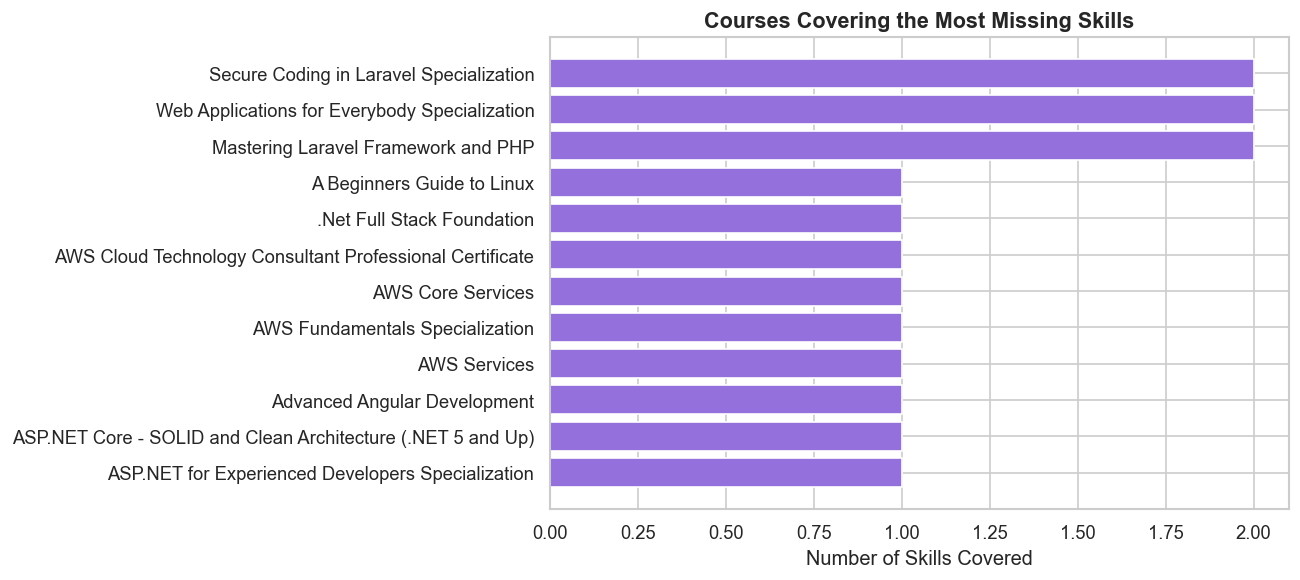

In [20]:
# Find courses that cover the most missing skills — prioritise those
if not recs_df.empty:
    coverage = (
        recs_df.groupby('course_name')['skill']
        .apply(list)
        .reset_index()
        .rename(columns={'skill': 'skills_covered'})
    )
    coverage['coverage_count'] = coverage['skills_covered'].apply(len)
    coverage = coverage.sort_values('coverage_count', ascending=False)

    print('Top courses by number of missing skills covered:')
    print(coverage.head(10).to_string(index=False))

    plt.figure(figsize=(11, 5))
    top_cov = coverage.head(12)
    plt.barh(top_cov['course_name'], top_cov['coverage_count'], color='mediumpurple')
    plt.title('Courses Covering the Most Missing Skills', fontsize=13, fontweight='bold')
    plt.xlabel('Number of Skills Covered')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Step 8: Personalised Recommendations Per Job

In [22]:
print('Personalised Learning Plan per Job:')
print('=' * 65)

job_rec_rows = []

for _, grow in gap_df.iterrows():
    missing = grow['missing_skills']
    if not missing:
        print(f"Rank {grow['rank']}: {grow['job_title']} — No missing skills!")
        continue

    print(f"\nRank {grow['rank']}: {grow['job_title']}")
    print(f"  Missing ({len(missing)}): {', '.join(missing)}")

    seen_for_job = set()
    for skill in missing:
        recs = recommend_courses(skill, top_k=3)
        for r in recs:
            if r['course_name'] in seen_for_job:
                continue
            seen_for_job.add(r['course_name'])
            print(f'    [{skill}] -> {r["course_name"]} '
                  f'({r["organization"]}, {r["difficulty"]}, ⭐{r["rating"]})')
            job_rec_rows.append({
                'job_rank':        grow['rank'],
                'job_title':       grow['job_title'],
                'missing_skill':   skill,
                'course_name':     r['course_name'],
                'organization':    r['organization'],
                'difficulty':      r['difficulty'],
                'rating':          r['rating'],
                'url':             r['url'],
                'similarity_score':r['similarity_score'],
                'weighted_score':  r['weighted_score']
            })

job_recs_df = pd.DataFrame(job_rec_rows)
print(f'\nTotal job-specific recommendations: {len(job_recs_df)}')

Personalised Learning Plan per Job:

Rank 1: Developer (Vue.JS / PHP, React Native & HTML/CSS & SQL) (ID: 610843)
  Missing (4): laravel, php, react, vue
    [laravel] -> Laravel: Configure, Validate, Authenticate and Authorize (Infosec, Beginner level, ⭐5.0)
    [laravel] -> Secure Coding in Laravel Specialization (Infosec, Beginner level, ⭐5.0)
    [laravel] -> Mastering Laravel Framework and PHP (Board Infinity, Intermediate level, ⭐4.2)
    [php] -> Building Database Applications in PHP (University of Michigan, Intermediate level, ⭐4.9)
    [php] -> Building Web Applications in PHP (University of Michigan, Intermediate level, ⭐4.7)
    [react] -> Advanced React Projects and Ecommerce Development (Packt, Intermediate level, ⭐Not rated)
    [react] -> Learn React (Scrimba, Intermediate level, ⭐4.7)
    [react] -> React Native (Meta, Intermediate level, ⭐4.8)

Rank 2: Analyst Programmer
  Missing (11): agile, aws, azure, communication, data mining, jquery, laravel, leadership, linux, 

## Step 9: Visualise Recommendations

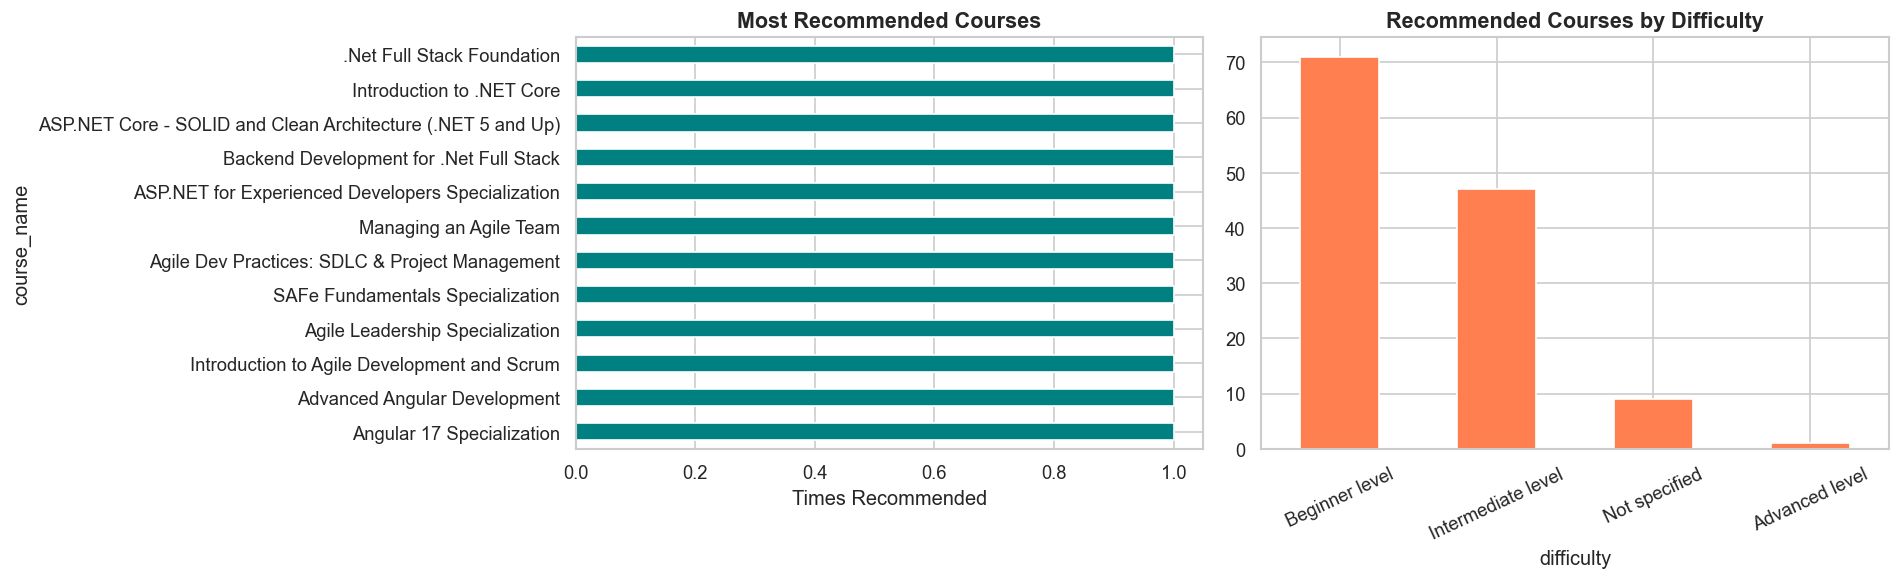

In [24]:
if not recs_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Most recommended courses
    top_courses = recs_df.drop_duplicates('course_name')['course_name'].value_counts().head(12)
    top_courses.plot(kind='barh', ax=axes[0], color='teal')
    axes[0].set_title('Most Recommended Courses', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Times Recommended')
    axes[0].invert_yaxis()

    # Difficulty breakdown
    if 'difficulty' in recs_df.columns:
        recs_df['difficulty'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
        axes[1].set_title('Recommended Courses by Difficulty', fontsize=13, fontweight='bold')
        axes[1].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.show()

## Step 10: Save Outputs

In [26]:
os.makedirs('data', exist_ok=True)

recs_df.to_csv('data/course_recommendations.csv', index=False)
job_recs_df.to_csv('data/job_course_recommendations.csv', index=False)
print('Saved: data/course_recommendations.csv')
print('Saved: data/job_course_recommendations.csv')

COURSE_APP_PATH   = 'data/coursera_cleaned.csv'
COURSE_VEC_PATH   = 'data/course_tfidf_vec.pkl'
COURSE_MAT_PATH   = 'data/course_tfidf_matrix.npz'
COURSE_EMB_PATH   = 'data/course_embs.npy'
COURSE_META_PATH  = 'data/course_index_meta.pkl'
SBERT_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

courses_df.to_csv(COURSE_APP_PATH, index=False)
print(f'Saved: {COURSE_APP_PATH}')

with open(COURSE_VEC_PATH, 'wb') as f:
    pickle.dump(course_vec, f)
save_npz(COURSE_MAT_PATH, course_matrix)
print(f'Saved: {COURSE_VEC_PATH}')
print(f'Saved: {COURSE_MAT_PATH}')

ready = False
if os.path.exists(COURSE_EMB_PATH) and os.path.exists(COURSE_META_PATH):
    try:
        with open(COURSE_META_PATH, 'rb') as f:
            meta = pickle.load(f)
        ready = meta.get('n_courses') == len(courses_df) and meta.get('model_name') == SBERT_NAME
    except Exception:
        ready = False

if ready:
    print('Course SBERT embeddings already saved.')
else:
    print('Building course SBERT embeddings...')
    model = SentenceTransformer(SBERT_NAME)
    course_embs = model.encode(
        courses_df['course_text'].fillna('').astype(str).tolist(),
        batch_size=64,
        normalize_embeddings=True,
        show_progress_bar=True
    )
    np.save(COURSE_EMB_PATH, course_embs)
    with open(COURSE_META_PATH, 'wb') as f:
        pickle.dump({'n_courses': len(courses_df), 'model_name': SBERT_NAME}, f)
    print(f'Saved: {COURSE_EMB_PATH}')
    print(f'Saved: {COURSE_META_PATH}')

job_recs_df.head(10)

Saved: data/course_recommendations.csv
Saved: data/job_course_recommendations.csv
Saved: data/coursera_cleaned.csv
Saved: data/course_tfidf_vec.pkl
Saved: data/course_tfidf_matrix.npz
Course SBERT embeddings already saved.


,job_rank,job_title,missing_skill,course_name,organization,difficulty,rating,url,similarity_score,weighted_score
0,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",laravel,"Laravel: Configure, Validate, Authenticate and...",Infosec,Beginner level,5.0,https://www.coursera.org/learn/secure-coding-i...,0.7084,0.7959
1,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",laravel,Secure Coding in Laravel Specialization,Infosec,Beginner level,5.0,https://www.coursera.org/specializations/secur...,0.5800,0.7060
2,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",laravel,Mastering Laravel Framework and PHP,Board Infinity,Intermediate level,4.2,https://www.coursera.org/learn/laravel-framewo...,0.5570,0.6419
3,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",php,Building Database Applications in PHP,University of Michigan,Intermediate level,4.9,https://www.coursera.org/learn/database-applic...,0.6689,0.7622
4,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",php,Building Web Applications in PHP,University of Michigan,Intermediate level,4.7,https://www.coursera.org/learn/web-application...,0.3767,0.5457
5,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",react,Advanced React Projects and Ecommerce Development,Packt,Intermediate level,Not rated,https://www.coursera.org/learn/packt-advanced-...,0.7277,0.7914
6,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",react,Learn React,Scrimba,Intermediate level,4.7,https://www.coursera.org/learn/learn-react,0.7058,0.7761
7,1,"Developer (Vue.JS / PHP, React Native & HTML/C...",react,React Native,Meta,Intermediate level,4.8,https://www.coursera.org/learn/react-native-co...,0.6395,0.7357
8,2,Analyst Programmer,agile,Managing an Agile Team,University of Virginia,Not specified,4.7,https://www.coursera.org/learn/uva-darden-agil...,0.6603,0.7442
9,2,Analyst Programmer,agile,Agile Dev Practices: SDLC & Project Management,Northeastern University,Beginner level,Not rated,https://www.coursera.org/learn/agile-dev-pract...,0.5486,0.6660
